In [1]:
# !pip install matplotlib
# !pip install scikit-learn
# !pip install statsmodels
# !pip install seaborn
# !pip install openpyxl

## Preprocessing

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np
import seaborn as sns

In [3]:
data = pd.read_excel('data/data.xlsx', header = 0, engine = 'openpyxl', nrows = 192)

In [4]:
data.head()

,Entity,Date,Rating,Rating Class,Rating PD,Cash and cash equivalents,Financial assets,Total Assets,Investment in associated entities,Accounts payable,...,US Treasury 5,US Treasury 10,ОFZ 2,OFZ 5,OFZ 10,IMOEX,ROE,Leverage,Insured by government,Captive
0,Алмазная Осень,44104,ruAA,2,0.004,1.978310e+08,3.609074e+10,3.683009e+10,0,338000.0,...,0.28,0.69,4.28,4.99,6.03,"2.905,81",0.103181,7.938218,1,0
1,Алмазная Осень,43942,ruAA,2,0.004,7.487060e+08,3.354566e+10,3.491423e+10,0,2008000.0,...,0.34,0.58,5.53,5.78,6.19,"2.488,02",0.054959,12.606684,1,0
2,Алмазная Осень,43614,ruAA,2,0.004,7.033770e+08,2.984306e+10,3.103310e+10,0,1428000.0,...,2.05,2.25,7.37,7.58,7.91,"2.641,15",0.231275,11.065649,1,0
3,Алмазная Осень,43255,ruAA,2,0.004,4.312370e+08,2.357436e+10,2.511377e+10,0,1261000.0,...,2.78,2.94,6.67,6.86,7.22,"2.323,64",0.269300,11.684484,1,0
4,Алмазная Осень,42899,ruAA,2,0.004,1.043698e+09,1.769658e+10,1.931554e+10,0,282000.0,...,1.79,2.21,8.00,7.82,7.64,"1.861,27",0.219727,12.190640,1,0


In [5]:
target = data['Rating PD'].to_numpy()

In [6]:
data = data.drop(labels = ['Entity', 'Date', 'Rating'], axis = 1)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Rating Class                       192 non-null    int64  
 1   Rating PD                          192 non-null    float64
 2   Cash and cash equivalents          192 non-null    float64
 3   Financial assets                   192 non-null    float64
 4   Total Assets                       192 non-null    float64
 5   Investment in associated entities  192 non-null    int64  
 6   Accounts payable                   192 non-null    float64
 7   Liabilities                        192 non-null    float64
 8   Pension liabilities                192 non-null    float64
 9   Equity                             192 non-null    float64
 10  Margin                             192 non-null    float64
 11  Total deposits                     192 non-null    float64
 12  Total

In [8]:
data_with_no_na = data.dropna()
print('Data with NA:', len(data))
print('Data without NA:', len(data_with_no_na))

Data with NA: 192
Data without NA: 172


In [9]:
data_with_no_na['IMOEX'] = data_with_no_na['IMOEX'].str.replace('.', '').str.replace(',', '.')
data_with_no_na['IMOEX'] = data_with_no_na['IMOEX'].astype(np.float32)

Fill missing value in "Total deposits", "Total payments"

This variables can be tied to the margin with a constant multiplier. Estimate the average multiplier and extrapolate on missing values

In [10]:
contributions = data_with_no_na['Total deposits'][data_with_no_na['Total deposits'] != 0].to_numpy()
payments = data_with_no_na['Total payments'][data_with_no_na['Total payments'] != 0].to_numpy()
profits = data_with_no_na['Margin'][data_with_no_na['Total payments'] != 0].to_numpy()
contrib_perc = (contributions / profits).mean()
payments_perc = (payments / profits).mean()
print('Average share of deposits to profit:', (contributions / profits).mean())
print('Average share of payments to profit:', (payments / profits).mean())

Average share of deposits to profit: 439.27493954799786
Average share of payments to profit: 268.39909984068703


In [11]:
data_with_no_na.loc[data_with_no_na['Total deposits'] == 0, 'Total deposits'] = data_with_no_na['Margin'][data_with_no_na['Total deposits'] == 0] * contrib_perc
data_with_no_na.loc[data_with_no_na['Total payments'] == 0, 'Total payments'] = data_with_no_na['Margin'][data_with_no_na['Total payments'] == 0] * payments_perc

## Outliers

In [12]:
from scipy import stats
import numpy as np
z = np.abs(stats.zscore(data_with_no_na.drop(labels = ['Insured by government', 'Captive', 'Rating Class'], axis = 1).dropna()))
threshold = 3
outliers = np.where(z > threshold)[0]
print("Outlier count:", len(np.unique(outliers)))

Outlier count: 39


In [13]:
from sklearn import preprocessing

x = data_with_no_na.drop(labels = ['Rating PD', 'Rating Class', 'Insured by government', 'Captive'], axis = 1).to_numpy()
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
index = data_with_no_na.columns.drop(labels = ['Rating Class', 'Rating PD', 'Insured by government', 'Captive'])
data_with_no_na[index] = x_scaled

In [14]:
data_with_no_na = data_with_no_na.reset_index().drop(index = outliers).drop(columns=["index"])

## Гистограмма

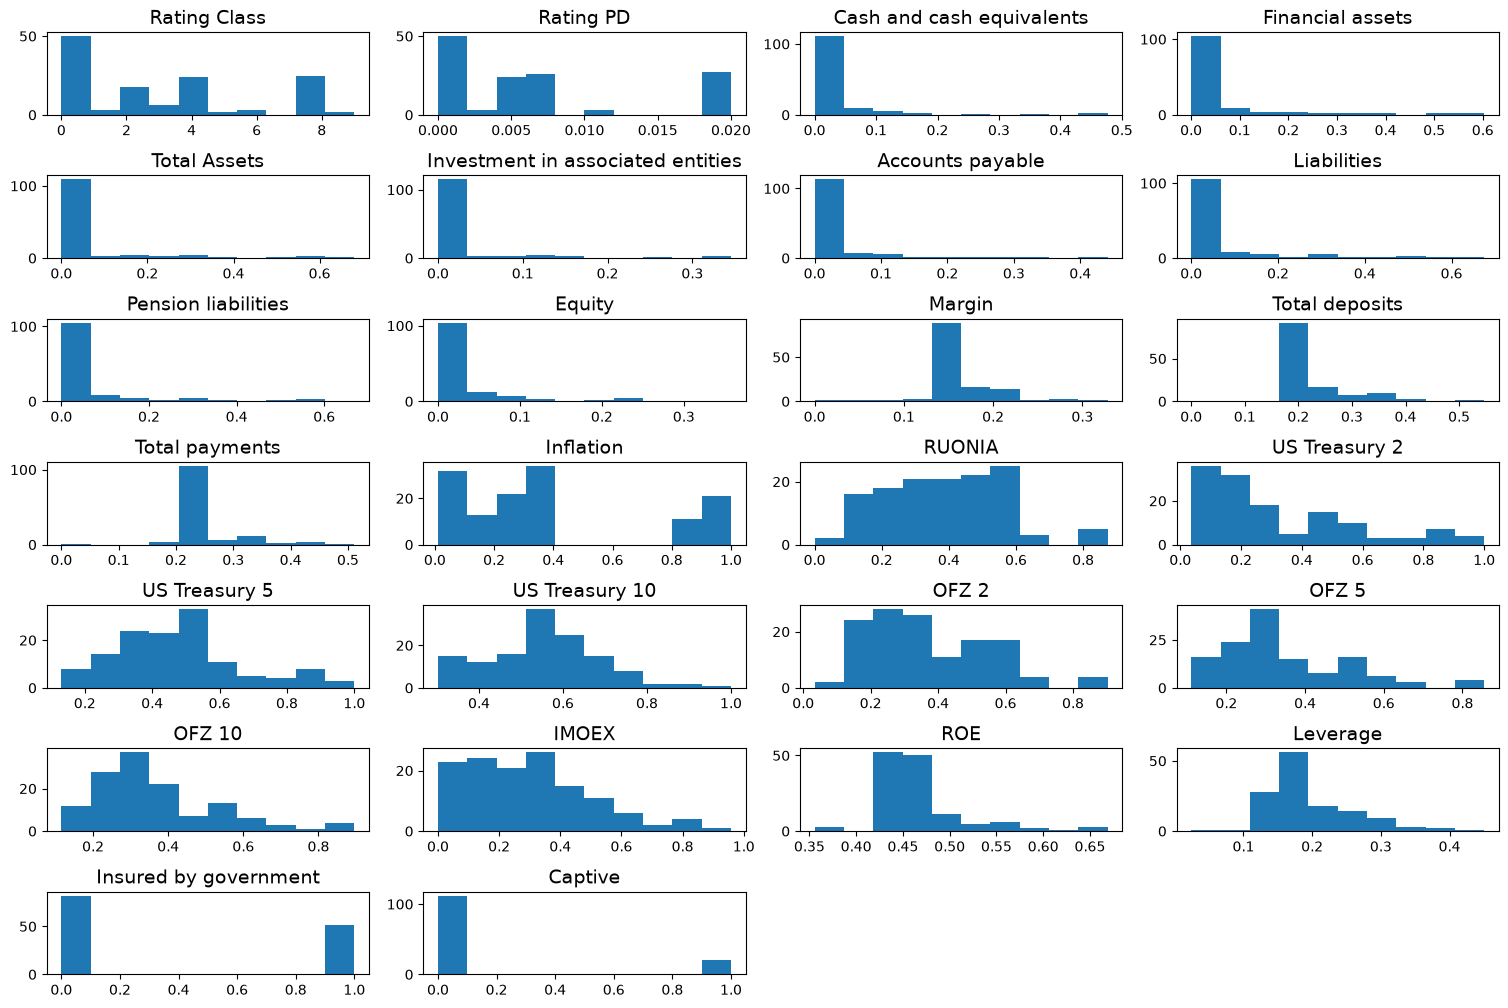

In [15]:
# Построим графики распределения основных переменных
f, ax = plt.subplots(nrows=7, ncols = 4, figsize = (15, 10))
for i in range(6):
    for j in range(4):
        ax[i][j].hist(data_with_no_na.iloc[:, j + 4 * i], bins = 10)
        ax[i][j].set_title(data_with_no_na.columns[j + 4 * i], fontsize = 14)
ax[6][0].hist(data_with_no_na['Insured by government'])
ax[6][0].set_title('Insured by government', fontsize = 14)
ax[6][1].set_title('Captive', fontsize = 14)
ax[6][1].hist(data_with_no_na['Captive'])
f.delaxes(ax[6, 2])
f.delaxes(ax[6, 3])
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.savefig('images/hist.png', dpi = 400)

In [16]:
# Non-informative
data_with_no_na = data_with_no_na.drop('Investment in associated entities', axis = 1)

In [17]:
len(data_with_no_na)

133

## Correlation

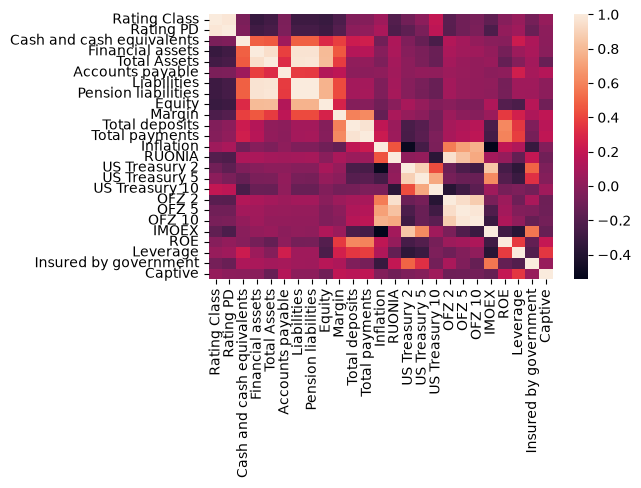

In [18]:
# Посмотрим корреляцию между переменными
import seaborn as sns
correlation_matrix = data_with_no_na.corr()
heat = sns.heatmap(correlation_matrix)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
heat.figure.savefig('images/heatmap.png', dpi = 400)

In [19]:
dataCorr = correlation_matrix[abs(correlation_matrix) >= 0.01].stack().reset_index()
dataCorr = dataCorr[dataCorr['level_0'].astype(str)!=dataCorr['level_1'].astype(str)]
 
# filtering out lower/upper triangular duplicates 
dataCorr['ordered-cols'] = dataCorr.apply(lambda x: '-'.join(sorted([x['level_0'],x['level_1']])),axis=1)
dataCorr = dataCorr.drop_duplicates(['ordered-cols'])
dataCorr.drop(['ordered-cols'], axis=1, inplace=True)
 
dataCorr.sort_values(by=[0], ascending=False).head(10) #Get 10 highest correlation of pairwaise attributes

,level_0,level_1,0
157,Liabilities,Pension liabilities,0.999839
1,Rating Class,Rating PD,0.981787
469,OFZ 5,OFZ 10,0.978076
107,Total Assets,Pension liabilities,0.975931
106,Total Assets,Liabilities,0.975793
261,Total deposits,Total payments,0.969116
82,Financial assets,Pension liabilities,0.966351
81,Financial assets,Liabilities,0.965533
342,RUONIA,ОFZ 2,0.953431
79,Financial assets,Total Assets,0.950023


In [20]:
data_with_no_na = data_with_no_na.drop(
    labels=['Total Assets', 
    'Liabilities', 
    'Total payments', 
    'Total deposits', 
    'ОFZ 2',
    'OFZ 5', 
    'OFZ 10'], 
    axis = 1)

**Removal:**

* Remove totals due to high correlation with other variables

* Keep only RUONIA instead of OFZ

* Remove payments and deposits as they are highy correlated with margin

## Model

In [43]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(data_with_no_na, test_size = 0.1, random_state = 42)

In [44]:
labels = ["Rating PD", "Rating Class"]
X_train_linear, Y_train_linear = df_train.drop(labels=labels, axis = 1), df_train['Rating PD']
X_test_linear, Y_test_linear = df_test.drop(labels=labels, axis = 1), df_test['Rating PD']

In [45]:
import statsmodels.api as sm
model = sm.OLS(Y_train_linear, sm.add_constant(X_train_linear))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Rating PD   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     1.772
Date:                Thu, 24 Sep 2026   Prob (F-statistic):             0.0453
Time:                        18:32:01   Log-Likelihood:                 428.59
No. Observations:                 119   AIC:                            -823.2
Df Residuals:                     102   BIC:                            -775.9
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.0092      0.010      0.890      0.376      -0.011       0.030
Cash and cash equivalents     0.0189      0.012      1.644      0.103      -0.004       0.042
Financial assets             -0.0175      0.035     -0.493      0.623      -0.088       0.053
Accounts payable              0.0078      0.012      0.664      0.508      -0.015       0.031
Pension liabilities           0.0103      0.030      0.340      0.735      -0.050       0.070
Equity                       -0.0377      0.023     -1.627      0.107      -0.084       0.008
Margin                       -0.0081      0.023     -0.352      0.726      -0.054       0.038
Inflation                     0.0037      0.003      1.108      0.270      -0.003       0.010
RUONIA                       -0.0091      0.008     -1.100      0.274      -0.026       0.007
US Treasury 2                 0.0008      0.014      0.058      0.954      -0.028       0.030
US Treasury 5                -0.0098      0.027     -0.366      0.715      -0.063       0.043
US Treasury 10                0.0166      0.022      0.751      0.454      -0.027       0.061
IMOEX                        -0.0037      0.008     -0.464      0.643      -0.019       0.012
ROE                           0.0030      0.018      0.172      0.864      -0.032       0.038
Leverage                     -0.0211      0.015     -1.391      0.167      -0.051       0.009
Insured by government         0.0019      0.002      1.101      0.273      -0.002       0.005
Captive                      -0.0003      0.002     -0.153      0.879      -0.004       0.004
==============================================================================
Omnibus:                        7.695   Durbin-Watson:                   2.355
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                5.451
Skew:                           0.392   Prob(JB):                       0.0655
Kurtosis:                       2.303   Cond. No.                         118.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Feature selection

Drop statistically insigificant features

In [57]:
from sklearn.metrics import mean_absolute_error

def recursive_select_features(X_train, Y_train, X_test, Y_test, threshold=0.05):
    columns = X_train.columns
    fitted = None
    while True:
        model = sm.OLS(Y_train, sm.add_constant(X_train[columns]))
        fitted = model.fit()
        Y_pred = fitted.predict(sm.add_constant(X_test[columns]))
        print("MAE: ", mean_absolute_error(Y_test, Y_pred))
        pvals = fitted.pvalues
        pvals.drop("const", errors="ignore")

        if pvals.empty or all(pvals <= threshold):
            break

        worst_column = pvals.index[np.argmax(pvals)]
        columns = columns.drop(worst_column)
        print(f"Dropped {worst_column}, pval={np.max(pvals)}")
    return fitted

In [58]:
linear_fitted = recursive_select_features(X_train_linear, Y_train_linear, X_test_linear, Y_test_linear)

MAE:  0.0037091572920162907
Dropped US Treasury 2, pval=0.9540795172118294
MAE:  0.0037008172798620115
Dropped Captive, pval=0.8812547924085439
MAE:  0.00371910567067204
Dropped ROE, pval=0.8502845656079441
MAE:  0.0036753728169936213
Dropped Margin, pval=0.7293486867559574
MAE:  0.003793096030797644
Dropped IMOEX, pval=0.6543137988299508
MAE:  0.003675261132303682
Dropped Pension liabilities, pval=0.5917053849494426
MAE:  0.003841552004487554
Dropped Financial assets, pval=0.5091037559180404
MAE:  0.003971484890843796
Dropped Accounts payable, pval=0.6203759099278093
MAE:  0.00400305311221198
Dropped Insured by government, pval=0.2502132839136712
MAE:  0.004158196405014725
Dropped US Treasury 5, pval=0.23184243436172208
MAE:  0.004306597614660696
Dropped US Treasury 10, pval=0.4828022556597014
MAE:  0.004299216282377306
Dropped Cash and cash equivalents, pval=0.13785760759841445
MAE:  0.004430938607640608
Dropped Leverage, pval=0.25901133270601184
MAE:  0.004462286291807729


In [60]:
linear_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Rating PD   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     7.210
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           0.000178
Time:                        18:34:05   Log-Likelihood:                 424.25
No. Observations:                 119   AIC:                            -840.5
Df Residuals:                     115   BIC:                            -829.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0112      0.002      6.748      0.000       0.008       0.015
Equity        -0.0348      0.012     -2.849      0.005      -0.059      -0.011
Inflation      0.0049      0.002      2.357      0.020       0.001       0.009
RUONIA        -0.0136      0.004     -3.203      0.002      -0.022      -0.005
==============================================================================
Omnibus:                       11.656   Durbin-Watson:                   2.470
Prob(Omnibus):                  0.003   Jarque-Bera (JB):                8.323
Skew:                           0.523   Prob(JB):                       0.0156
Kurtosis:                       2.235   Cond. No.                         22.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
significant_columns = linear_fitted.params.index.drop("const")

## Polynomial features

Degree 2 is not significant

In [65]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_features= PolynomialFeatures(degree=2)
X_train_polynomial = polynomial_features.fit_transform(X_train_linear[significant_columns])
X_test_polynomial = polynomial_features.transform(X_test_linear[significant_columns])

polynomial_model = sm.OLS(Y_train_linear, sm.add_constant(X_train_polynomial))
polynomial_fitted = polynomial_model.fit()
polynomial_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Rating PD   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     3.051
Date:                Thu, 24 Sep 2026   Prob (F-statistic):            0.00270
Time:                        18:34:59   Log-Likelihood:                 427.37
No. Observations:                 119   AIC:                            -834.7
Df Residuals:                     109   BIC:                            -806.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0156      0.004      3.656      0.000       0.007       0.024
x1            -0.0948      0.041     -2.310      0.023      -0.176      -0.013
x2            -0.0063      0.011     -0.580      0.563      -0.028       0.015
x3            -0.0152      0.018     -0.821      0.414      -0.052       0.021
x4             0.2129      0.135      1.578      0.118      -0.055       0.480
x5            -0.0298      0.042     -0.711      0.479      -0.113       0.053
x6             0.0442      0.063      0.704      0.483      -0.080       0.169
x7             0.0018      0.011      0.171      0.865      -0.019       0.023
x8             0.0214      0.027      0.790      0.431      -0.032       0.075
x9            -0.0151      0.031     -0.485      0.629      -0.077       0.046
==============================================================================
Omnibus:                        7.594   Durbin-Watson:                   2.366
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                6.135
Skew:                           0.455   Prob(JB):                       0.0465
Kurtosis:                       2.360   Cond. No.                         275.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [66]:
Y_pred = polynomial_fitted.predict(X_test_polynomial)
print(mean_absolute_error(Y_test_linear, Y_pred))

0.00421560583596913


## Predicting PD

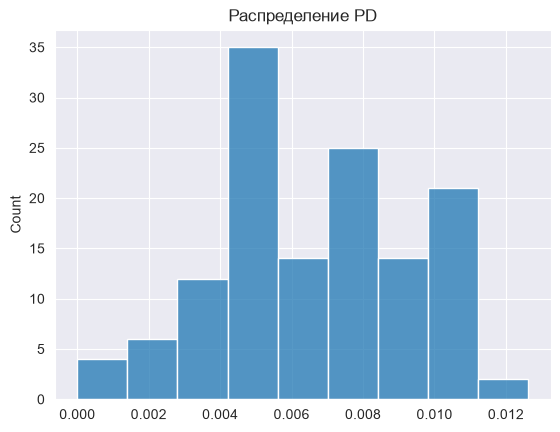

In [75]:
X = data_with_no_na[significant_columns]
prediction = np.maximum(0, linear_fitted.predict(sm.add_constant(X)).to_numpy())
fig, ax = plt.subplots()

sns.set_style("darkgrid")

sns.histplot(prediction)

ax.set_title('Распределение PD')

plt.show()
fig.savefig('images/pd_dist.png')

## Logit

Feature selection. Logit does not prove to be an adequate solution

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

from sklearn.metrics import accuracy_score
list_columns = ['Rating Class']

df_train, df_test = train_test_split(data_with_no_na, test_size = 0.1, random_state = 42)
best_n_features_to_select = 0
best_accuracy = 0.0
for n_features_to_select in range(1, len(df_train.columns)):
    X_train_logit, Y_train_logit = df_train.drop(columns='Rating Class'), df_train['Rating Class'].astype(int)
    X_test_logit, Y_test_logit = df_test.drop(columns = 'Rating Class'), df_test['Rating Class'].astype(int)
    model = RFE(LogisticRegression(), n_features_to_select=n_features_to_select).fit(X_train_logit, Y_train_logit)
    pred = model.predict(X_test_logit)
    accuracy = accuracy_score(pred, Y_test_logit)
    print(f"Features: {X_train_logit.loc[:, model.support_].columns}")
    print(f"Accuracy: {accuracy}")

    if accuracy > best_accuracy:
        best_n_features_to_select = n_features_to_select
        best_accuracy = accuracy

Features: Index(['US Treasury 2'], dtype='str')
Accuracy: 0.5714285714285714
Features: Index(['US Treasury 2', 'Insured by government'], dtype='str')
Accuracy: 0.5
Features: Index(['Inflation', 'US Treasury 2', 'Insured by government'], dtype='str')
Accuracy: 0.5
Features: Index(['Inflation', 'US Treasury 2', 'Insured by government', 'Captive'], dtype='str')
Accuracy: 0.5
Features: Index(['Inflation', 'US Treasury 2', 'IMOEX', 'Insured by government',
       'Captive'],
      dtype='str')
Accuracy: 0.5
Features: Index(['Pension liabilities', 'Inflation', 'US Treasury 2', 'IMOEX',
       'Insured by government', 'Captive'],
      dtype='str')
Accuracy: 0.5
Features: Index(['Pension liabilities', 'Inflation', 'US Treasury 2', 'US Treasury 5',
       'IMOEX', 'Insured by government', 'Captive'],
      dtype='str')
Accuracy: 0.5
Features: Index(['Financial assets', 'Pension liabilities', 'Inflation', 'US Treasury 2',
       'US Treasury 5', 'IMOEX', 'Insured by government', 'Captive'],
   

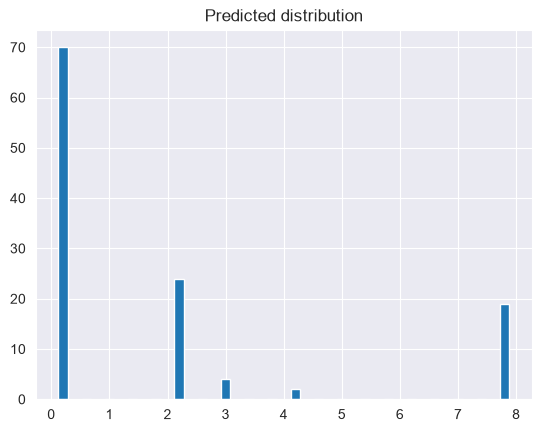

In [ ]:
X, Y = df_train.drop(columns = 'Rating Class'), df_train['Rating Class'].astype(int)
pred = model.predict(X)
fig, ax = plt.subplots()

ax.hist(pred, bins = 20, rwidth = 0.4)

ax.set_title('Predicted distribution')

plt.show()
fig.savefig('images/rate_dist.png')